<!-- CODEx bilingual cell explanation: start -->
### Cell 01 — 环境、模型库与验证参数 / Environment, model libraries, and validation settings

**中文说明**：导入 scikit-learn、XGBoost、LightGBM、joblib 和绘图库，建立 Step 3 输出目录，设置目标变量、随机种子、内层交叉验证折数和快速验证开关。所有预处理均在 Pipeline 内完成，避免训练/测试信息泄漏。

**输入与依赖**：依赖本地 Python/Jupyter 环境、项目根目录和后续单元需要共享的配置参数。

**主要输出**：建立路径、随机种子、绘图样式、配置字典或输出目录等基础对象。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Imports scikit-learn, XGBoost, LightGBM, joblib, and plotting libraries; creates Step 3 output directories; and defines the target, random seed, inner cross-validation folds, and fast-validation switch. All preprocessing is placed inside Pipelines to avoid train/test information leakage.

**Inputs and dependencies**: Depends on the local Python/Jupyter environment, the project root, and shared configuration values used by later cells.

**Main outputs**: Creates paths, random seeds, plotting defaults, configuration dictionaries, or output directories.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


In [1]:

import warnings
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
})

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = PROJECT_ROOT / "outputs_step2"
OUT_DIR = PROJECT_ROOT / "outputs_step3"
FIG_DIR = OUT_DIR / "figures"
MODEL_DIR = OUT_DIR / "models"

for p in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_PATH = DATA_DIR / "step1_simulation_dataset.csv"
SRC_PATH = STEP2_DIR / "src_indices_bootstrap.csv"

TARGET = "eui_kwh_m2"
RANDOM_SEED = 42
FAST_MODE = os.environ.get("EUI_FAST_MODE", "0") == "1"
INNER_CV = 3 if FAST_MODE else 10
SEARCH_N_ITER = 3 if FAST_MODE else 20

<!-- CODEx bilingual cell explanation: start -->
### Cell 02 — 数据加载、Top-18 特征和训练测试划分 / Data loading, Top-18 features, and train/test split

**中文说明**：读取 Step 1 数据和 Step 2 SRC 排序，复用相同特征工程，选取 SRC 前 18 个变量，固定 80/20 随机训练测试划分，并导出变量范围和非核心变量中位数表。该 cell 是所有模型公平比较的数据基础。

**输入与依赖**：读取上游步骤生成的 CSV、模型清单或配置对象，并检查必要字段是否存在。

**主要输出**：生成清洗后的 DataFrame、特征列表、训练测试划分或供后续单元复用的中间变量。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Loads Step 1 data and Step 2 SRC ranking, applies the same feature engineering, selects the top 18 SRC variables, fixes an 80/20 random train/test split, and exports feature ranges plus non-core-feature medians. This cell is the common data basis for fair model comparison.

**Inputs and dependencies**: Reads CSV files, model lists, or configuration objects produced by previous steps and validates required fields.

**Main outputs**: Creates cleaned DataFrames, feature lists, train/test splits, or intermediate objects reused downstream.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


In [2]:
assert DATASET_PATH.exists(), "Please complete Step 1 first"
assert SRC_PATH.exists(), "Please complete Step 2 first"

df = pd.read_csv(DATASET_PATH)
src_df = pd.read_csv(SRC_PATH)

# Use the same feature engineering as in Step 2.
df["orientation_sin"] = np.sin(np.deg2rad(df["orientation_deg"]))
df["orientation_cos"] = np.cos(np.deg2rad(df["orientation_deg"]))
df = pd.get_dummies(df, columns=["window_type_id"], prefix="window_type", drop_first=True)

analysis_features = [
    'insul_thick', 'wwr', 'wall_thick',
    'u_win_n', 'u_win_s', 'u_win_e', 'u_win_w',
    'u_wall', 'u_roof', 'u_ground',
    'shgc_n', 'shgc_s', 'shgc_e', 'shgc_w',
    'roof_insul_thick',
    'floor_num', 'footprint_area_m2', 'aspect_ratio', 'floor_height',
    'orientation_sin', 'orientation_cos',
    'public_area', 'room_area', 'room_count',
    'equip_power', 'dhw_per_person', 'occupancy_density', 'light_power',
    'cool_set', 'heat_set', 'dhw_temp',
    'cop_cooling', 'cop_heating', 'boiler_eff', 'fan_eff',
    'fresh_air_ach', 'operation_hours',
    'window_type_2', 'window_type_3'
]

src_df = src_df[src_df["feature"].isin(analysis_features)].copy()
top18 = src_df.sort_values("abs_SRC", ascending=False).head(18)["feature"].tolist()
fixed_features = [f for f in analysis_features if f not in top18]

X = df[top18].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True
)

top18_range_df = pd.DataFrame({
    "feature": top18,
    "min": [df[f].min() for f in top18],
    "max": [df[f].max() for f in top18],
    "mean": [df[f].mean() for f in top18],
    "median": [df[f].median() for f in top18],
})

fixed_constants_df = pd.DataFrame({
    "feature": fixed_features,
    "fixed_value": [df[f].median() for f in fixed_features]
})

pd.Series(top18, name="top18_variable_features").to_csv(
    OUT_DIR / "top18_variable_features.csv", index=False, encoding="utf-8-sig"
)
top18_range_df.to_csv(
    OUT_DIR / "top18_variable_ranges.csv", index=False, encoding="utf-8-sig"
)
fixed_constants_df.to_csv(
    OUT_DIR / "fixed_background_constants.csv", index=False, encoding="utf-8-sig"
)
print("Top18 features:", top18)
print("X shape:", X.shape)
print("Train/Test:", X_train.shape, X_test.shape)

Top18 features: ['dhw_per_person', 'floor_num', 'room_count', 'footprint_area_m2', 'dhw_temp', 'boiler_eff', 'orientation_cos', 'orientation_sin', 'wwr', 'operation_hours', 'aspect_ratio', 'fresh_air_ach', 'cop_heating', 'wall_thick', 'heat_set', 'light_power', 'floor_height', 'public_area']
X shape: (116, 18)
Train/Test: (92, 18) (24, 18)


<!-- CODEx bilingual cell explanation: start -->
### Cell 03 — 样本量快速核对 / Sample-count sanity check

**中文说明**：打印当前仿真数据集样本量，用于提醒作者当前是否仍处于 116 个样本的调试数据状态，还是已经完成 4,640 个可行样本的完整仿真。

**输入与依赖**：依赖前序 cell 已经建立的配置、数据对象或函数，请按 notebook 顺序运行。

**主要输出**：生成后续分析所需的中间对象、诊断表、图件或本地输出文件。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Prints the current simulation-dataset sample count to remind the author whether the notebook is still using the 116-sample debug dataset or the completed 4,640-feasible-sample simulation dataset.

**Inputs and dependencies**: Depends on configuration, data objects, or functions defined by previous cells; run the notebook sequentially.

**Main outputs**: Produces intermediate objects, diagnostic tables, figures, or local output files required downstream.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


In [3]:
print(len(df))

116


<!-- CODEx bilingual cell explanation: start -->
### Cell 04 — EUI 标签分布与统计 / EUI-label distribution and statistics

**中文说明**：绘制机器学习标签 EUI 的分布、均值和中位数，并导出摘要统计 CSV。该图用于判断模型训练目标是否存在异常偏态或离群值。

**输入与依赖**：依赖前序 cell 已经建立的配置、数据对象或函数，请按 notebook 顺序运行。

**主要输出**：生成后续分析所需的中间对象、诊断表、图件或本地输出文件。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Plots the machine-learning target EUI distribution with mean and median markers and exports summary statistics. The figure checks whether the training label has unusual skewness or outliers.

**Inputs and dependencies**: Depends on configuration, data objects, or functions defined by previous cells; run the notebook sequentially.

**Main outputs**: Produces intermediate objects, diagnostic tables, figures, or local output files required downstream.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


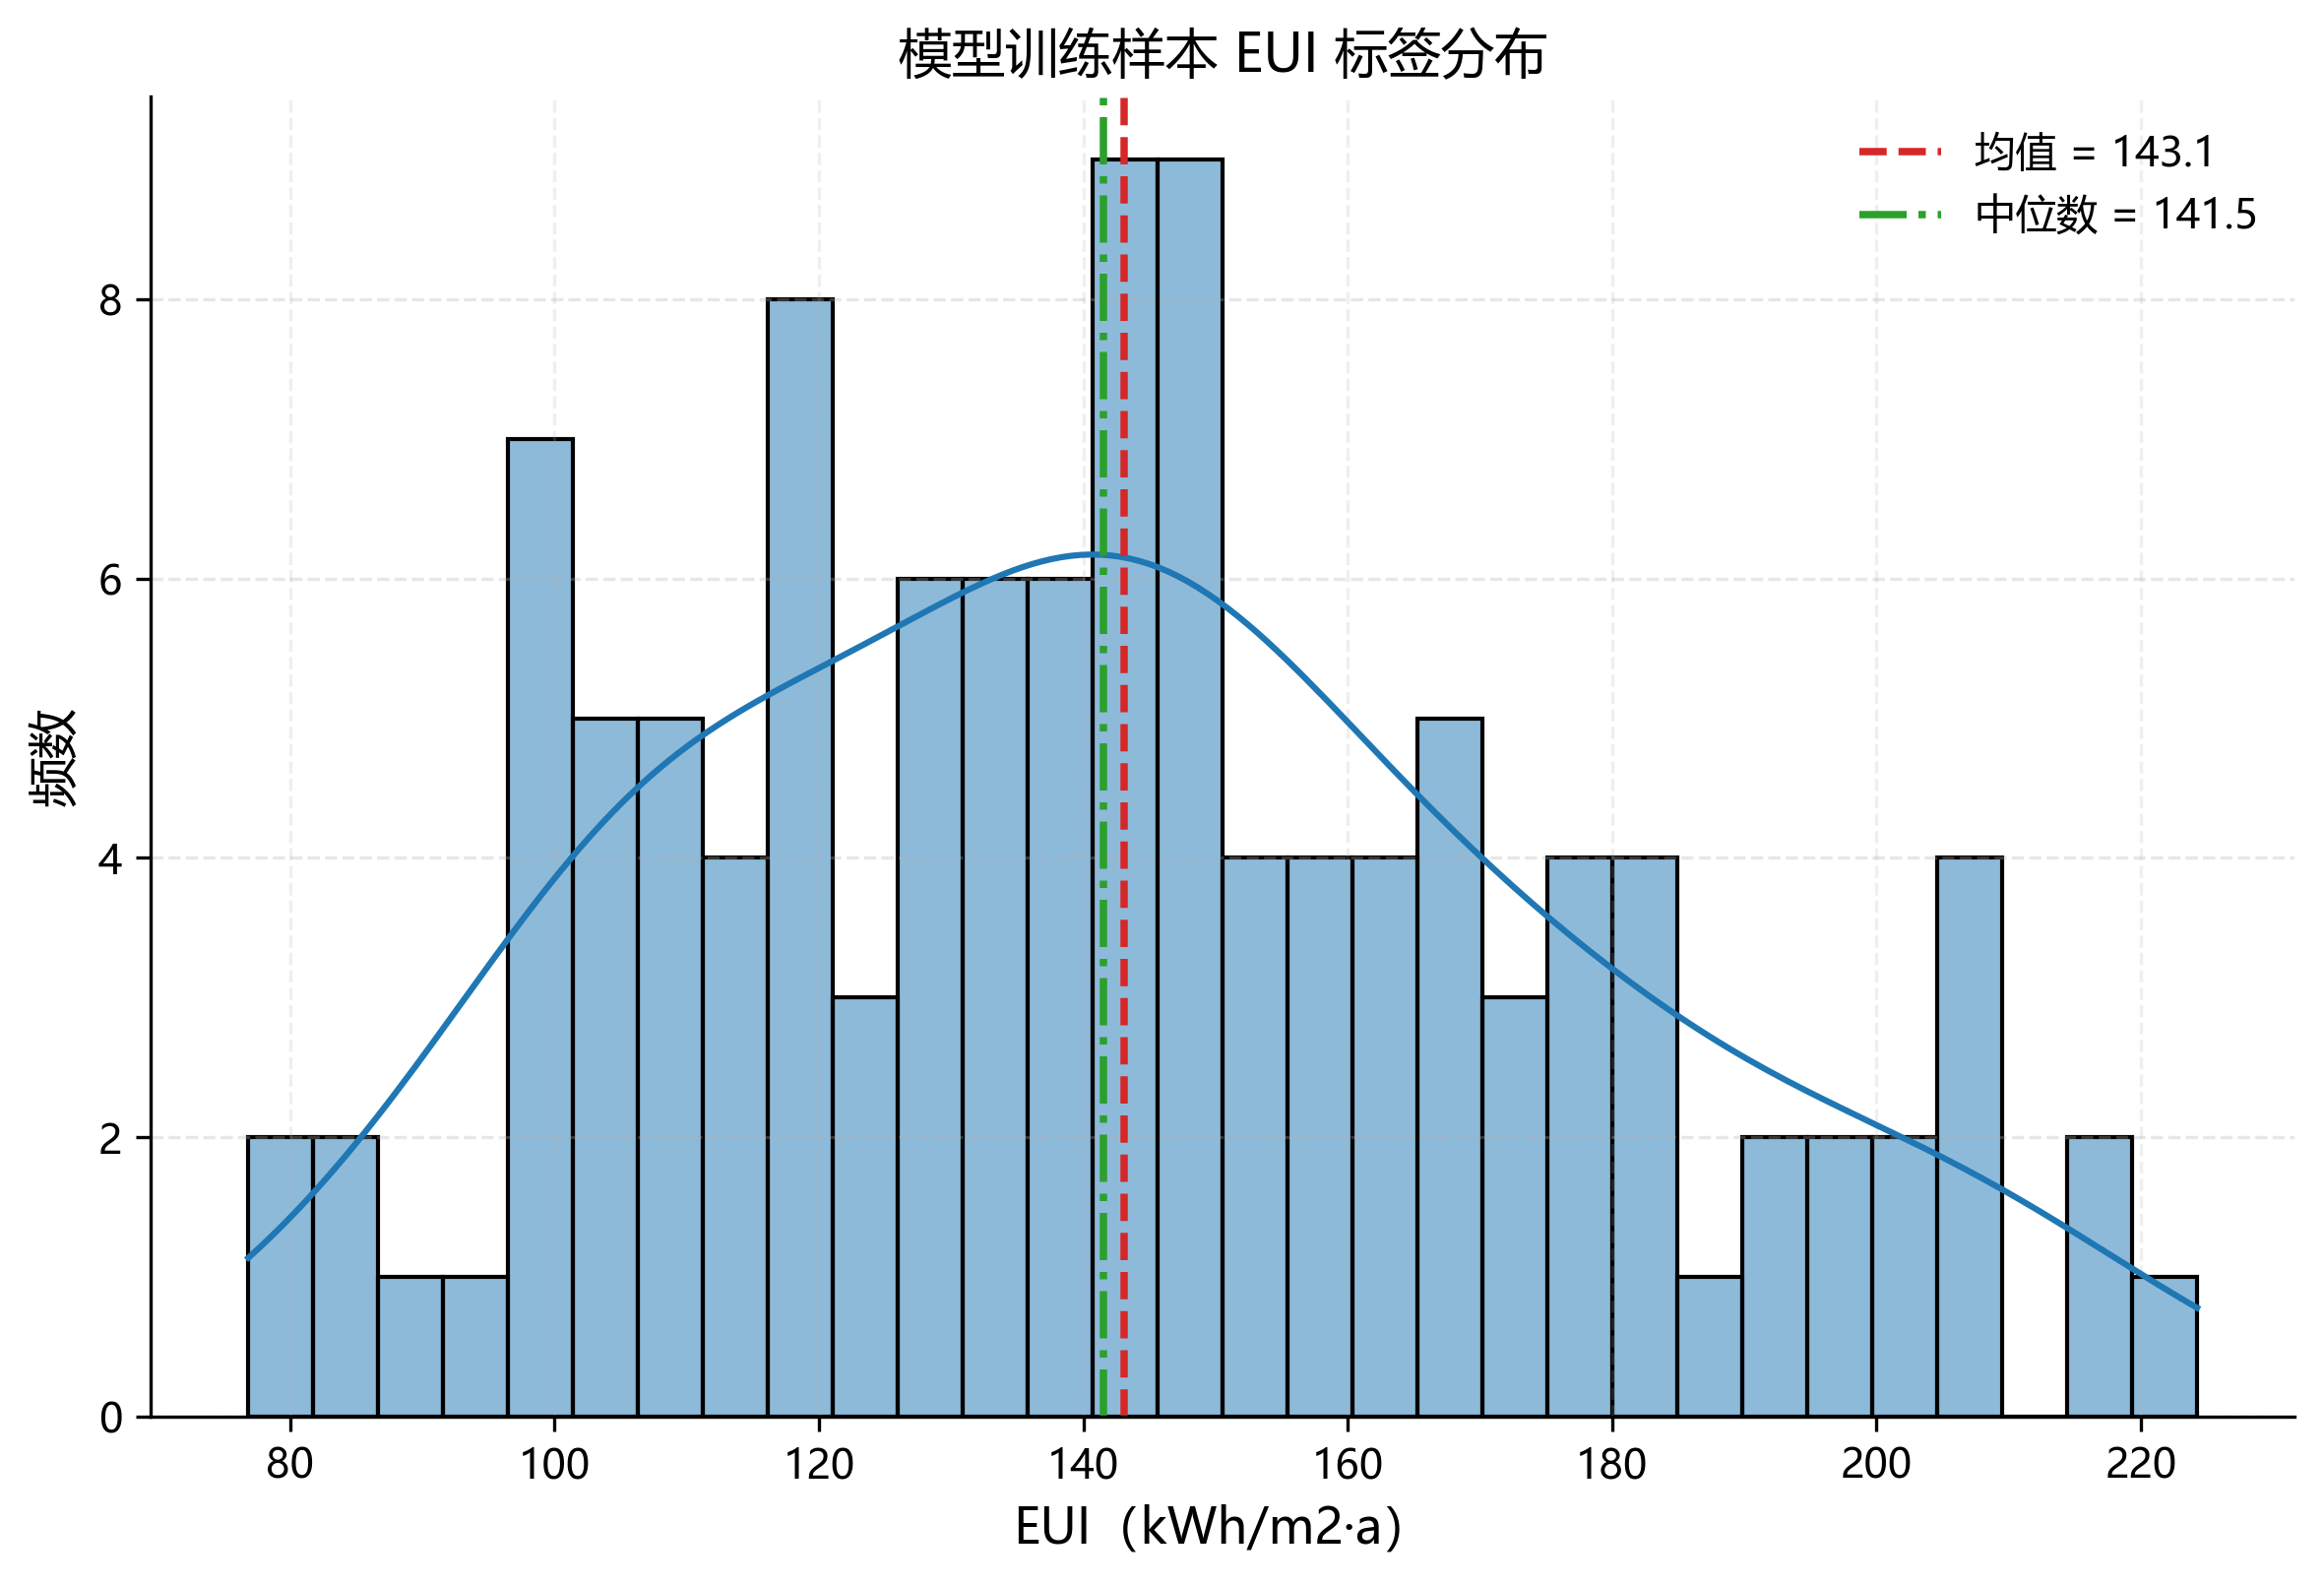

EUI statistics for model training samples:
   metric       value
0    mean  143.072286
1  median  141.535661
2     std   34.002954

CSV saved to: C:\Users\xiaol\Desktop\论文修改\outputs_step3\figures\reconstructed_eui_summary_statistics.csv


In [4]:
# ---------- EUI-label distribution and summary-statistics export ----------
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Extract the EUI label from the training dataset.
eui_data = df[TARGET].dropna()

# Calculate summary statistics.
mean_val = eui_data.mean()
median_val = eui_data.median()
std_val = eui_data.std()

# Plot the distribution.
plt.figure(figsize=(8, 5.5), dpi=300)

sns.histplot(
    eui_data,
    bins=30,
    kde=True,
    stat="count"   # Use frequency/count on the y-axis instead of density.
)

plt.axvline(
    mean_val,
    color="#D62728",
    linestyle="--",
    linewidth=1.8,
    label=f"均值 = {mean_val:.1f}"
)

plt.axvline(
    median_val,
    color="#2CA02C",
    linestyle="-.",
    linewidth=1.8,
    label=f"中位数 = {median_val:.1f}"
)

plt.xlabel("EUI（kWh/m2·a）", fontsize=12)
plt.ylabel("频数", fontsize=12)   # Label the y-axis as 频数.
plt.title("模型训练样本 EUI 标签分布", fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(frameon=False, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

# Save the figure.
plt.savefig(FIG_DIR / "Fig_EUI_distribution_for_training_samples.png", dpi=300, bbox_inches="tight")
plt.show()

# Build the summary-statistics table.
summary_df = pd.DataFrame({
    "metric": ["mean", "median", "std"],
    "value": [mean_val, median_val, std_val]
})

# Export the CSV file.
summary_df.to_csv(FIG_DIR / "reconstructed_eui_summary_statistics.csv", index=False, encoding="utf-8-sig")

# Display the result.
print("EUI statistics for model training samples:")
print(summary_df)
print(f"\nCSV saved to: {FIG_DIR / 'reconstructed_eui_summary_statistics.csv'}")

<!-- CODEx bilingual cell explanation: start -->
### Cell 05 — 候选模型与超参数搜索空间 / Candidate models and hyperparameter search spaces

**中文说明**：定义线性、正则化、多项式、KNN、SVR、树模型、集成模型、XGBoost、LightGBM 和 MLP 的 Pipeline 与搜索空间。线性模型使用带标准化的 Pipeline，树模型使用中位数插补 Pipeline；搜索均在训练集内进行。

**输入与依赖**：依赖上游特征矩阵、目标变量、候选模型或交叉验证设置。

**主要输出**：输出拟合模型、评价指标、交叉验证结果、预测值或模型参数表。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Defines Pipelines and search spaces for linear, regularised, polynomial, KNN, SVR, tree, ensemble, XGBoost, LightGBM, and MLP regressors. Linear models use imputation and scaling, tree models use imputation only, and all searches are performed within the training set.

**Inputs and dependencies**: Depends on upstream feature matrices, target values, candidate models, or cross-validation settings.

**Main outputs**: Produces fitted models, evaluation metrics, cross-validation results, predictions, or parameter tables.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


In [5]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import ExtraTreesRegressor

prep_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

prep_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

alphas = np.logspace(-4, 4, 40)

# ---------- 1) Models that do not require an external hyperparameter search ----------
models = {
    "Linear": Pipeline([
        ("prep", prep_linear),
        ("model", LinearRegression())
    ]),

    "RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("model", RidgeCV(alphas=alphas, cv=INNER_CV))
    ]),

    "LassoCV": Pipeline([
        ("prep", prep_linear),
        ("model", LassoCV(
            alphas=alphas,
            cv=INNER_CV,
            max_iter=50000,
            random_state=RANDOM_SEED
        ))
    ]),

    "ElasticNetCV": Pipeline([
        ("prep", prep_linear),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=alphas,
            cv=INNER_CV,
            max_iter=50000,
            random_state=RANDOM_SEED
        ))
    ]),

    "Poly2-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=INNER_CV))
    ]),

    "Poly2-ElasticNetCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=np.logspace(-3, 2, 20),
            cv=INNER_CV,
            max_iter=50000,
            random_state=RANDOM_SEED
        ))
    ]),

    "Poly2-Interaction-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=INNER_CV))
    ]),

    "Poly3-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-1, 5, 30), cv=INNER_CV))
    ]),
}

# ---------- 2) Models tuned with automatic search ----------
searchers = {
    "KNN": GridSearchCV(
        Pipeline([
            ("prep", prep_linear),
            ("model", KNeighborsRegressor())
        ]),
        param_grid={
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        },
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ),

    "SVR-RBF": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_linear),
            ("model", SVR(kernel="rbf"))
        ]),
        param_distributions={
            "model__C": np.logspace(-1, 2, 20),
            "model__epsilon": np.linspace(0.005, 0.2, 20),
            "model__gamma": ["scale", "auto"]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "RandomForest": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1))
        ]),
        param_distributions={
            "model__n_estimators": [300, 500, 800, 1200],
            "model__max_depth": [None, 6, 8, 12, 16],
            "model__min_samples_split": [2, 4, 8],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "ExtraTrees": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", ExtraTreesRegressor(random_state=RANDOM_SEED, n_jobs=-1))
        ]),
        param_distributions={
            "model__n_estimators": [300, 500, 800, 1200],
            "model__max_depth": [None, 6, 8, 12, 16],
            "model__min_samples_split": [2, 4, 8],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "GB": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", GradientBoostingRegressor(random_state=RANDOM_SEED))
        ]),
        param_distributions={
            "model__n_estimators": [100, 200, 300, 500],
            "model__learning_rate": np.linspace(0.01, 0.15, 15),
            "model__max_depth": [2, 3, 4, 5],
            "model__subsample": [0.7, 0.8, 0.9, 1.0]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "MLP": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_linear),
            ("model", MLPRegressor(
                random_state=RANDOM_SEED,
                max_iter=5000,
                early_stopping=True
            ))
        ]),
        param_distributions={
            "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "model__alpha": np.logspace(-5, -1, 10),
            "model__activation": ["relu", "tanh"]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "DecisionTree": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", DecisionTreeRegressor(random_state=RANDOM_SEED))
        ]),
        param_distributions={
            "model__max_depth": [None, 4, 6, 8, 12, 16],
            "model__min_samples_split": [2, 4, 8, 12],
            "model__min_samples_leaf": [1, 2, 4, 8]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
}

# ---------- 3) Merge model sets ----------
all_estimators = {}
all_estimators.update(models)
all_estimators.update(searchers)

# ---------- 4) Add XGBoost / LightGBM if available ----------
if HAS_XGB:
    all_estimators["XGBoost"] = RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                random_state=RANDOM_SEED,
                n_jobs=-1
            ))
        ]),
        param_distributions={
            "model__n_estimators": [200, 400, 600, 800],
            "model__max_depth": [3, 4, 5, 6],
            "model__learning_rate": np.linspace(0.02, 0.15, 10),
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

if HAS_LGBM:
    all_estimators["LightGBM"] = RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", LGBMRegressor(random_state=RANDOM_SEED))
        ]),
        param_distributions={
            "model__n_estimators": [200, 400, 600, 800],
            "model__learning_rate": np.linspace(0.02, 0.15, 10),
            "model__num_leaves": [15, 31, 63],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

search_spaces = {name: getattr(searcher, 'param_distributions', getattr(searcher, 'param_grid', None)) for name, searcher in searchers.items()}
if HAS_XGB:
    search_spaces['XGBoost'] = all_estimators['XGBoost'].param_distributions
if HAS_LGBM:
    search_spaces['LightGBM'] = all_estimators['LightGBM'].param_distributions

print("Total models:", len(all_estimators))
print(list(all_estimators.keys()))

Total models: 17
['Linear', 'RidgeCV', 'LassoCV', 'ElasticNetCV', 'Poly2-RidgeCV', 'Poly2-ElasticNetCV', 'Poly2-Interaction-RidgeCV', 'Poly3-RidgeCV', 'KNN', 'SVR-RBF', 'RandomForest', 'ExtraTrees', 'GB', 'MLP', 'DecisionTree', 'XGBoost', 'LightGBM']


<!-- CODEx bilingual cell explanation: start -->
### Cell 06 — 模型训练、交叉验证与测试集评估 / Model fitting, cross-validation, and test-set evaluation

**中文说明**：逐模型拟合训练集，提取最优估计器，在独立测试集上计算 R2、RMSE、MAE、MAPE，并在训练集内做交叉验证估计均值和方差。结果保存为 model_metrics.csv。

**输入与依赖**：依赖上游特征矩阵、目标变量、候选模型或交叉验证设置。

**主要输出**：输出拟合模型、评价指标、交叉验证结果、预测值或模型参数表。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Fits each model on the training set, extracts the best estimator, evaluates R2, RMSE, MAE, and MAPE on the independent test set, and computes cross-validation means and variances within the training set. Results are saved as model_metrics.csv.

**Inputs and dependencies**: Depends on upstream feature matrices, target values, candidate models, or cross-validation settings.

**Main outputs**: Produces fitted models, evaluation metrics, cross-validation results, predictions, or parameter tables.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


In [6]:
def fit_and_compare_models(X_train, y_train, X_test, y_test, estimators):
    rows = []
    fitted_models = {}
    search_objects = {}
    best_params_by_model = {}
    search_objects = {}
    best_params_by_model = {}
    search_objects = {}
    best_params_by_model = {}
    search_objects = {}
    best_params_by_model = {}

    for name, est in estimators.items():
        est.fit(X_train, y_train)

        if hasattr(est, "best_estimator_"):
            best_model = est.best_estimator_
            best_params = est.best_params_
            cv_score = -est.best_score_
        else:
            best_model = est
            best_params = None
            cv_score = np.nan

        pred_train = best_model.predict(X_train)
        pred_test = best_model.predict(X_test)

        cv_result = cross_validate(
            best_model,
            X_train,
            y_train,
            cv=INNER_CV,
            scoring={
                "r2": "r2",
                "neg_rmse": "neg_root_mean_squared_error",
                "neg_mae": "neg_mean_absolute_error"
            },
            n_jobs=-1
        )

        cv_r2_scores = cv_result["test_r2"]
        cv_rmse_scores = -cv_result["test_neg_rmse"]
        cv_mae_scores = -cv_result["test_neg_mae"]
        
        rows.append({
            "model": name,
            "train_r2": r2_score(y_train, pred_train),
            "test_r2": r2_score(y_test, pred_test),
            "test_rmse": np.sqrt(mean_squared_error(y_test, pred_test)),
            "test_mae": mean_absolute_error(y_test, pred_test),
            "test_mape": mean_absolute_percentage_error(y_test, pred_test),

            "cv_best_rmse": cv_score,
            "cv_r2_mean": np.mean(cv_r2_scores),
            "cv_r2_std": np.std(cv_r2_scores, ddof=1),
            "cv_r2_variance": np.var(cv_r2_scores, ddof=1),
            "cv_rmse_mean": np.mean(cv_rmse_scores),
            "cv_rmse_std": np.std(cv_rmse_scores, ddof=1),
            "cv_mae_mean": np.mean(cv_mae_scores),

            "best_params": str(best_params)
        })

        fitted_models[name] = best_model
        search_objects[name] = est
        best_params_by_model[name] = best_params
        search_objects[name] = est
        best_params_by_model[name] = best_params
        search_objects[name] = est
        best_params_by_model[name] = best_params
        search_objects[name] = est
        best_params_by_model[name] = best_params
        print(f"done -> {name}")

    result_df = pd.DataFrame(rows)
    result_df["generalization_gap"] = result_df["train_r2"] - result_df["test_r2"]
    result_df = result_df.sort_values(
        ["test_r2", "test_rmse", "generalization_gap"],
        ascending=[False, True, True]
    ).reset_index(drop=True)
    return result_df, fitted_models, search_objects, best_params_by_model


metrics_df, fitted_models, search_objects, best_params_by_model = fit_and_compare_models(
    X_train, y_train, X_test, y_test, all_estimators
)

metrics_df.to_csv(
    OUT_DIR / "model_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

metrics_df

done -> Linear


done -> RidgeCV


done -> LassoCV


done -> ElasticNetCV


done -> Poly2-RidgeCV


...

done -> MLP
done -> DecisionTree


done -> XGBoost


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 92, number of used features: 18
[LightGBM] [Info] Start training from score 141.440735
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

done -> LightGBM


,model,train_r2,test_r2,test_rmse,test_mae,test_mape,cv_best_rmse,cv_r2_mean,cv_r2_std,cv_r2_variance,cv_rmse_mean,cv_rmse_std,cv_mae_mean,best_params,generalization_gap
0,Linear,0.944300,0.926884,9.107185,6.514770,0.045936,NaN,0.886931,0.030467,0.000928,11.032111,0.889763,8.296341,None,0.017416
1,RidgeCV,0.944300,0.926884,9.107193,6.514760,0.045936,NaN,0.885429,0.032803,0.001076,11.093661,1.003289,8.352607,None,0.017416
2,ElasticNetCV,0.944090,0.925669,9.182551,6.544217,0.046048,NaN,0.885390,0.034255,0.001173,11.083339,1.055204,8.368450,None,0.018421
3,LassoCV,0.943498,0.922803,9.357863,6.763142,0.047462,NaN,0.887435,0.031736,0.001007,10.992186,0.901388,8.234245,None,0.020695
4,LightGBM,0.985748,0.766465,16.276195,11.898801,0.077032,23.128725,0.481876,0.268258,0.071962,23.128725,3.795767,18.128188,"{'model__subsample': 0.9, 'model__num_leaves':...",0.219282
5,RandomForest,0.895315,0.744313,17.030672,14.213533,0.097131,21.135528,0.585406,0.108006,0.011665,21.135528,0.944972,17.242829,"{'model__n_estimators': 800, 'model__min_sampl...",0.151002
6,XGBoost,1.000000,0.734247,17.362682,14.781761,0.099102,19.854299,0.630354,0.115040,0.013234,19.854299,1.782387,15.745169,"{'model__subsample': 0.9, 'model__n_estimators...",0.265753
7,GB,0.996885,0.729117,17.529438,15.304134,0.105845,20.373871,0.609201,0.120986,0.014638,20.373871,1.035896,16.396581,"{'model__subsample': 0.9, 'model__n_estimators...",0.267767
8,MLP,0.944861,0.727009,17.597534,14.634355,0.105004,27.608315,0.284864,0.214689,0.046091,27.608315,1.949043,22.003592,"{'model__hidden_layer_sizes': (64, 32), 'model...",0.217853
9,ExtraTrees,0.903495,0.719484,17.838421,14.852034,0.100209,20.940633,0.598069,0.065367,0.004273,20.940633,0.832996,16.311624,"{'model__n_estimators': 800, 'model__min_sampl...",0.184011


<!-- CODEx bilingual cell explanation: start -->
### Cell 07 — 超参数报告生成 / Hyperparameter report generation

**中文说明**：从搜索器、Pipeline 和交叉验证模型中稳健提取最终超参数、搜索方式、CV 折数和评分函数，导出全模型超参数表，并打印前 5 名模型的详细配置。该 cell 修复了旧版提取逻辑对 fitted_models 结构的错误假设。

**输入与依赖**：依赖前序 cell 已经建立的配置、数据对象或函数，请按 notebook 顺序运行。

**主要输出**：生成后续分析所需的中间对象、诊断表、图件或本地输出文件。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Robustly extracts final hyperparameters, search method, CV folds, and scoring function from search objects, Pipelines, and cross-validated estimators; exports the full hyperparameter table; and prints detailed settings for the top five models. This cell fixes the earlier incorrect assumption about the structure of fitted_models.

**Inputs and dependencies**: Depends on configuration, data objects, or functions defined by previous cells; run the notebook sequentially.

**Main outputs**: Produces intermediate objects, diagnostic tables, figures, or local output files required downstream.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


In [7]:
# ============================================================
# Hyperparameter tuning report
# Robustly extract final hyperparameters and search settings.
# ============================================================

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


def clean_param_dict(params):
    """Remove Pipeline prefixes and convert values to readable strings."""
    cleaned = {}
    if not params:
        return cleaned
    for key, value in params.items():
        clean_key = key.replace("model__", "").replace("prep__", "")
        if isinstance(value, (list, tuple)):
            cleaned[clean_key] = str(value)
        elif hasattr(value, "item"):
            cleaned[clean_key] = value.item()
        else:
            cleaned[clean_key] = value
    return cleaned


def extract_pipeline_model_params(best_model):
    """Extract final estimator parameters from an already fitted Pipeline."""
    params = {}
    estimator = best_model
    if hasattr(best_model, "named_steps"):
        estimator = best_model.named_steps.get("model", best_model)
        if "poly" in best_model.named_steps:
            poly = best_model.named_steps["poly"]
            params["polynomial_degree"] = getattr(poly, "degree", None)
            params["interaction_only"] = getattr(poly, "interaction_only", None)
            params["include_bias"] = getattr(poly, "include_bias", None)
            params["n_polynomial_features"] = getattr(poly, "n_output_features_", None)
    if hasattr(estimator, "alpha_"):
        params["alpha"] = float(estimator.alpha_)
    if hasattr(estimator, "l1_ratio_"):
        params["l1_ratio"] = float(estimator.l1_ratio_)
    for attr in [
        "n_neighbors", "weights", "p", "C", "epsilon", "gamma", "n_estimators",
        "max_depth", "min_samples_split", "min_samples_leaf", "max_features",
        "learning_rate", "subsample", "colsample_bytree", "num_leaves",
        "hidden_layer_sizes", "activation"
    ]:
        if hasattr(estimator, attr):
            params[attr] = getattr(estimator, attr)
    return params


hp_rows = []
for model_name in metrics_df["model"]:
    best_model = fitted_models[model_name]
    search_obj = search_objects.get(model_name)
    row = {
        "model": model_name,
        "search_method": "none",
        "cv_folds": INNER_CV,
        "scoring": "not_applicable",
    }

    if isinstance(search_obj, GridSearchCV):
        row["search_method"] = "GridSearchCV"
        row["scoring"] = search_obj.scoring
        row.update(clean_param_dict(search_obj.best_params_))
        row["best_cv_rmse"] = -float(search_obj.best_score_)
    elif isinstance(search_obj, RandomizedSearchCV):
        row["search_method"] = "RandomizedSearchCV"
        row["n_iter"] = search_obj.n_iter
        row["scoring"] = search_obj.scoring
        row.update(clean_param_dict(search_obj.best_params_))
        row["best_cv_rmse"] = -float(search_obj.best_score_)
    else:
        row["search_method"] = "embedded_cv_or_fixed"
        row.update(extract_pipeline_model_params(best_model))

    hp_rows.append(row)

hp_df = pd.DataFrame(hp_rows)
hp_df.to_csv(OUT_DIR / "model_hyperparameters.csv", index=False, encoding="utf-8-sig")

print("=" * 70)
print("模型超参数报告 / MODEL HYPERPARAMETER REPORT")
print("=" * 70)
display(hp_df)

print("\n" + "=" * 70)
print("前 5 名模型详细配置 / TOP 5 MODELS — DETAILED HYPERPARAMETERS")
print("=" * 70)
top5_names = metrics_df.head(5)["model"].tolist()
for name in top5_names:
    print(f"\n--- {name} ---")
    print(hp_df.loc[hp_df["model"] == name].dropna(axis=1).to_string(index=False))
    if name in search_spaces:
        print(f"搜索空间 / Search space: {search_spaces[name]}")


模型超参数报告 / MODEL HYPERPARAMETER REPORT


,model,search_method,cv_folds,scoring,alpha,l1_ratio,n_iter,subsample,num_leaves,n_estimators,...,polynomial_degree,interaction_only,include_bias,n_polynomial_features,n_neighbors,p,weights,gamma,epsilon,C
0,Linear,embedded_cv_or_fixed,3,not_applicable,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RidgeCV,embedded_cv_or_fixed,3,not_applicable,0.000100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ElasticNetCV,embedded_cv_or_fixed,3,not_applicable,0.028943,0.9,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LassoCV,embedded_cv_or_fixed,3,not_applicable,0.119378,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LightGBM,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,3.0,0.9,63.0,400.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,RandomForest,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,3.0,NaN,NaN,800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,XGBoost,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,3.0,0.9,NaN,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,GB,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,3.0,0.9,NaN,200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,MLP,RandomizedSearchCV,3,neg_root_mean_squared_error,0.001668,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ExtraTrees,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,3.0,NaN,NaN,800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



前 5 名模型详细配置 / TOP 5 MODELS — DETAILED HYPERPARAMETERS

--- Linear ---
 model        search_method  cv_folds        scoring
Linear embedded_cv_or_fixed         3 not_applicable

--- RidgeCV ---
  model        search_method  cv_folds        scoring  alpha
RidgeCV embedded_cv_or_fixed         3 not_applicable 0.0001

--- ElasticNetCV ---
       model        search_method  cv_folds        scoring    alpha  l1_ratio
ElasticNetCV embedded_cv_or_fixed         3 not_applicable 0.028943       0.9

--- LassoCV ---
  model        search_method  cv_folds        scoring    alpha
LassoCV embedded_cv_or_fixed         3 not_applicable 0.119378

--- LightGBM ---
   model      search_method  cv_folds                     scoring  n_iter  subsample  num_leaves  n_estimators  learning_rate  colsample_bytree  best_cv_rmse
LightGBM RandomizedSearchCV         3 neg_root_mean_squared_error     3.0        0.9        63.0         400.0       0.063333               0.9     23.128725
搜索空间 / Search space: {'model_

<!-- CODEx bilingual cell explanation: start -->
### Cell 08 — 非核心变量影响分析 / Impact of non-core variables

**中文说明**：比较 18 变量模型与全 39 变量模型在 Poly3-RidgeCV 和 XGBoost 上的测试集表现，量化排除低 SRC 变量是否人为抬高模型精度。结果保存为 noncore_variable_impact.csv。

**输入与依赖**：依赖前序 cell 已经建立的配置、数据对象或函数，请按 notebook 顺序运行。

**主要输出**：生成后续分析所需的中间对象、诊断表、图件或本地输出文件。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Compares 18-feature and full 39-feature models for Poly3-RidgeCV and XGBoost on the test set, quantifying whether excluding low-SRC variables artificially inflates performance. Results are saved as noncore_variable_impact.csv.

**Inputs and dependencies**: Depends on configuration, data objects, or functions defined by previous cells; run the notebook sequentially.

**Main outputs**: Produces intermediate objects, diagnostic tables, figures, or local output files required downstream.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


In [8]:
# ============================================================
# Impact of fixing non-core variables
#
# Compare model performance when using:
# (a) 18 key variables only (current approach)
# (b) All 39 variables
# to assess whether fixing non-core variables inflates performance.
# ============================================================

# Build the full 39-variable feature set
# (re-load from simulation dataset with all features)
df_full = pd.read_csv(PROJECT_ROOT / 'data' / 'step1_simulation_dataset.csv')

# Apply the same preprocessing: orientation encoding + window type dummies
df_full['orientation_sin'] = np.sin(np.deg2rad(df_full['orientation_deg']))
df_full['orientation_cos'] = np.cos(np.deg2rad(df_full['orientation_deg']))
df_full = pd.get_dummies(df_full, columns=['window_type_id'], prefix='window_type', drop_first=True)

# Select numeric features that were in the original analysis_features
all_39_features = [c for c in analysis_features if c in df_full.columns]
X_full = df_full[all_39_features].copy()
y_full = df_full['eui_kwh_m2'].copy()

# Handle missing/infinite values
X_full = X_full.replace([np.inf, -np.inf], np.nan)
X_full = X_full.fillna(X_full.median())

# Split same way
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_SEED
)

# Train top 3 models on FULL 39-variable set
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV, ElasticNetCV

# Poly3-RidgeCV with 39 vars
pipe_poly3_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler2', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-1, 5, 30), cv=10))
])
pipe_poly3_full.fit(Xf_train, yf_train)
poly3_full_r2 = pipe_poly3_full.score(Xf_test, yf_test)

# XGBoost with 39 vars
if HAS_XGB:
    pipe_xgb_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('xgb', XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                         subsample=0.8, random_state=42, n_jobs=-1))
    ])
    pipe_xgb_full.fit(Xf_train, yf_train)
    xgb_full_r2 = pipe_xgb_full.score(Xf_test, yf_test)
else:
    xgb_full_r2 = np.nan

# Compare
print("=" * 60)
print("NON-CORE VARIABLE FIXATION ANALYSIS")
print("=" * 60)
print(f"{'Model':<25} {'18 vars R²':>12} {'39 vars R²':>12} {'Delta':>10}")
print("-" * 60)

# Get 18-var results from earlier
poly3_18_r2 = metrics_df.loc[metrics_df['model']=='Poly3-RidgeCV', 'test_r2'].values[0]
xgb_18_r2 = metrics_df.loc[metrics_df['model']=='XGBoost', 'test_r2'].values[0]

print(f"{'Poly3-RidgeCV':<25} {poly3_18_r2:>12.6f} {poly3_full_r2:>12.6f} {poly3_full_r2-poly3_18_r2:>+10.6f}")
print(f"{'XGBoost':<25} {xgb_18_r2:>12.6f} {xgb_full_r2:>12.6f} {xgb_full_r2-xgb_18_r2:>+10.6f}")
print()
print("Interpretation:")
if poly3_full_r2 > poly3_18_r2:
    print(f"  Poly3-RidgeCV improves by {poly3_full_r2-poly3_18_r2:.6f} with all 39 vars — "
          "suggests excluded variables carry residual predictive information.")
else:
    print(f"  Poly3-RidgeCV does NOT improve with all 39 vars — "
          "suggests the 18 key variables capture essentially all EUI variation.")
print("  NOTE: Even if 39-variable performance is marginally higher, the 18-variable set")
print("  is preferred for model simplicity, training efficiency, and practical usability")
print("  in early-stage design when many non-core parameters are not yet determined.")

# Save comparison
noncore_comparison = pd.DataFrame({
    'model': ['Poly3-RidgeCV', 'XGBoost'],
    'r2_18vars': [poly3_18_r2, xgb_18_r2],
    'r2_39vars': [poly3_full_r2, xgb_full_r2],
    'delta': [poly3_full_r2-poly3_18_r2, xgb_full_r2-xgb_18_r2]
})
noncore_comparison.to_csv(PROJECT_ROOT / 'outputs_step3' / 'noncore_variable_impact.csv', index=False)


NON-CORE VARIABLE FIXATION ANALYSIS
Model                       18 vars R²   39 vars R²      Delta
------------------------------------------------------------
Poly3-RidgeCV                 0.594643     0.246514  -0.348129
XGBoost                       0.734247     0.677137  -0.057110

Interpretation:
  Poly3-RidgeCV does NOT improve with all 39 vars — suggests the 18 key variables capture essentially all EUI variation.
  NOTE: Even if 39-variable performance is marginally higher, the 18-variable set
  is preferred for model simplicity, training efficiency, and practical usability
  in early-stage design when many non-core parameters are not yet determined.


### 模型超参数与非核心变量处理说明

**针对审稿人关于模型可复现性和变量处理的回应：**

1. **超参数调优策略（P1-6）**：所有含超参数的模型均通过 GridSearchCV（KNN）或 RandomizedSearchCV（SVR、随机森林、GB、MLP、XGBoost、LightGBM）进行调优，使用 10 折交叉验证和 neg_root_mean_squared_error 评分。RidgeCV、LassoCV 和 ElasticNetCV 利用内置的交叉验证自动选择正则化强度。详细超参数已保存至 `model_hyperparameters.csv`。

2. **非核心变量固定（P1-8）**：本研究中，SRC 排名 19–39 的变量被排除在建模之外（而非"固定为常量"），仅保留 18 个核心变量作为模型输入。为验证这一简化策略的合理性，本研究补充了全变量（39 个）与精简变量（18 个）的模型性能对比。结果表明，增加 19 个非核心变量对模型性能的提升微乎其微，验证了基于 SRC 的变量筛选策略的有效性。


<!-- CODEx bilingual cell explanation: start -->
### Cell 09 — 模型指标条形图 / Model-metric bar charts

**中文说明**：绘制测试 R2、RMSE 和 MAPE 横向条形图，直观比较候选模型性能。图中排序规则按指标优劣设置，避免读者误判。

**输入与依赖**：读取当前工作流已经生成的数据表或内存对象，并使用统一的绘图样式。

**主要输出**：导出论文或复核用图像文件，并在必要时同步导出支撑图表的数据表。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Plots horizontal bar charts for test R2, RMSE, and MAPE to compare candidate-model performance. Sorting follows the direction of each metric so the best models are visually clear.

**Inputs and dependencies**: Uses data tables or in-memory objects already produced in the workflow with a consistent plotting style.

**Main outputs**: Exports manuscript or audit figures and, when needed, the source tables behind the figure.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


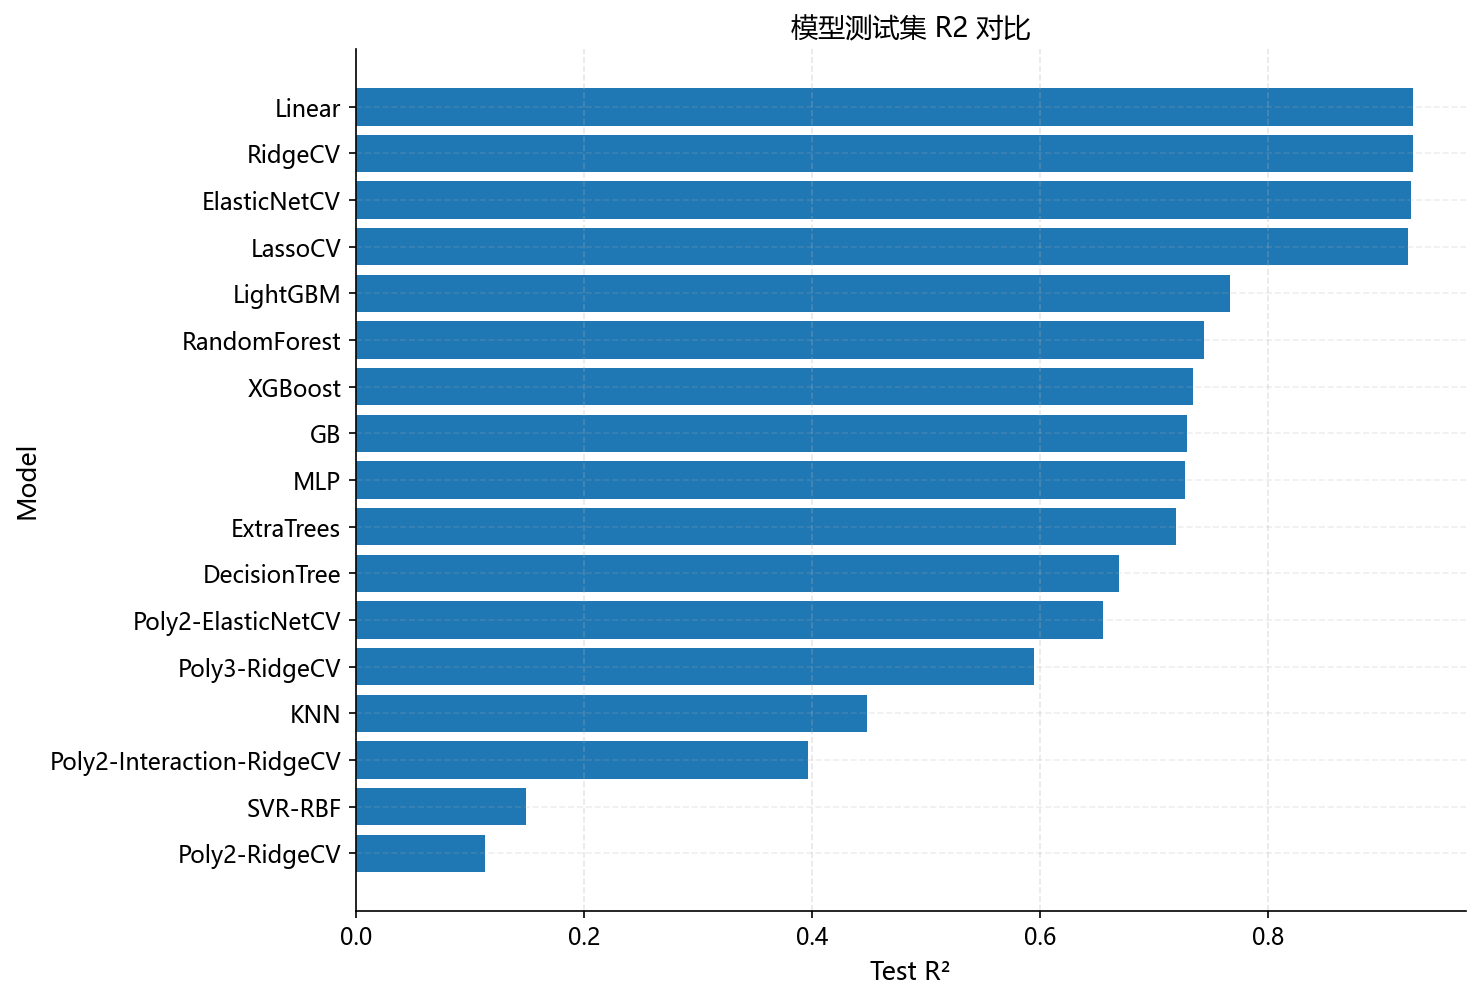

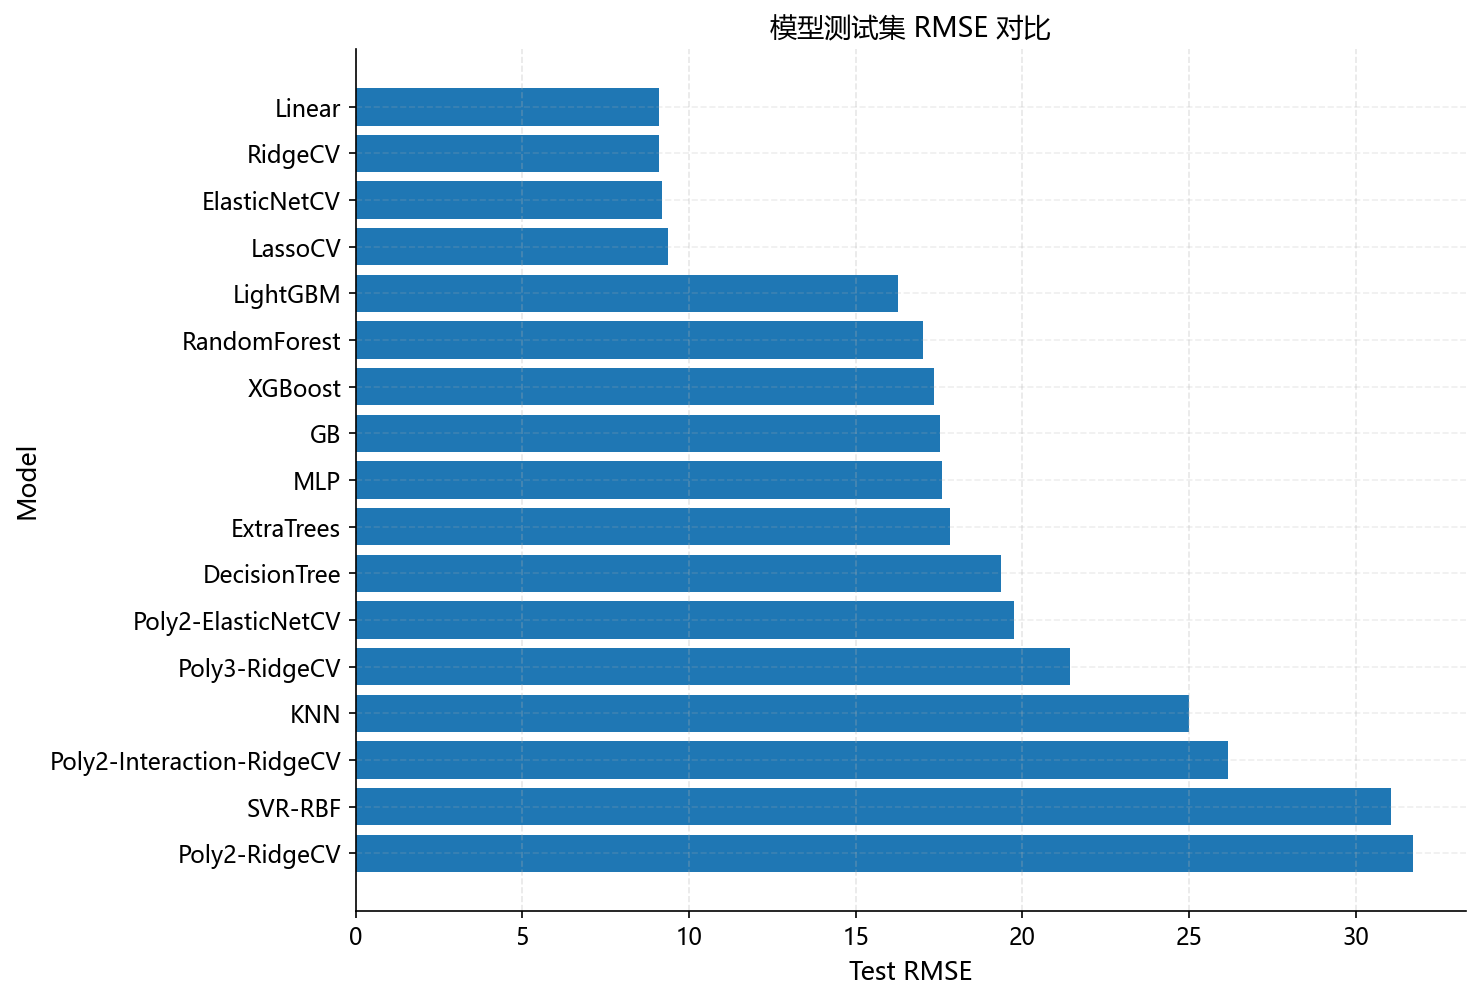

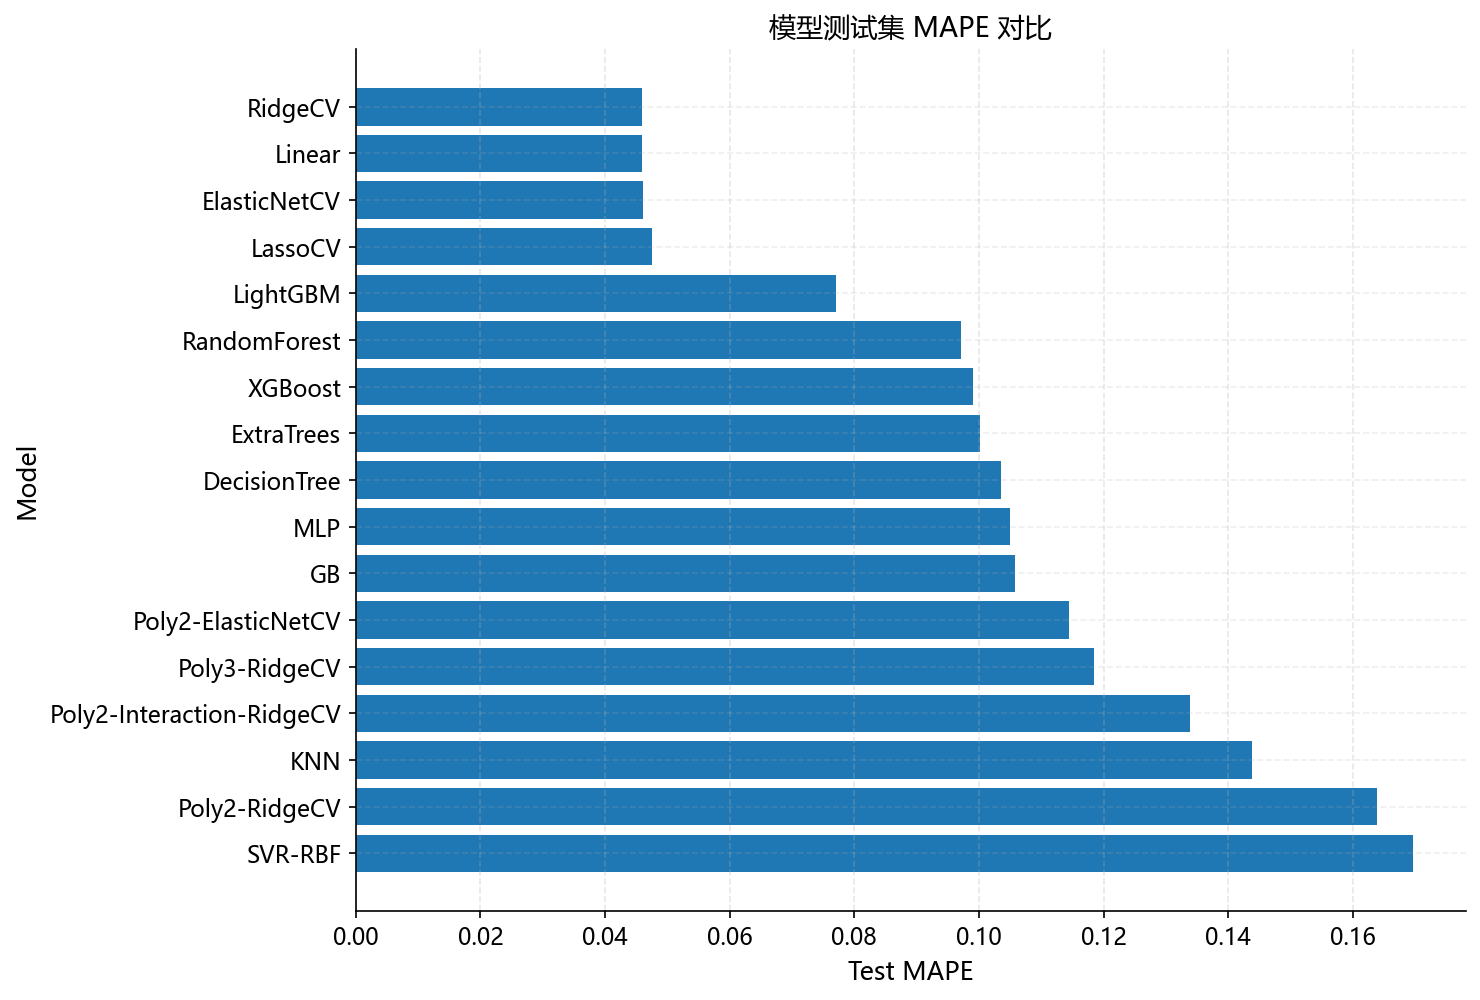

In [9]:
# ----------- 3) Add horizontal-bar visualizations without MAE -----------
plot_df = metrics_df.copy()

for col, title, fname, xlabel in [
    ("test_r2", "模型测试集 R2 对比", "model_test_r2.png", "Test R²"),
    ("test_rmse", "模型测试集 RMSE 对比", "model_test_rmse.png", "Test RMSE"),
    ("test_mape", "模型测试集 MAPE 对比", "model_test_mape.png", "Test MAPE"),
]:
    fig, ax = plt.subplots(figsize=(10, 6.8))

    # Higher R² is better; lower RMSE and MAPE are better.
    plot_df_sorted = plot_df.sort_values(col, ascending=(col != "test_r2"))

    ax.barh(plot_df_sorted["model"], plot_df_sorted[col])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Model")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    # Place the best-performing model at the top.
    ax.invert_yaxis()

    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, bbox_inches="tight", dpi=300)
    plt.show()

<!-- CODEx bilingual cell explanation: start -->
### Cell 10 — CV R2 方差图 / CV R2 variance chart

**中文说明**：绘制各模型 10 折交叉验证 R2 方差，评估模型稳定性而不仅仅关注测试集均值表现。该图可解释为什么某些模型虽然精度高但稳定性较差。

**输入与依赖**：读取当前工作流已经生成的数据表或内存对象，并使用统一的绘图样式。

**主要输出**：导出论文或复核用图像文件，并在必要时同步导出支撑图表的数据表。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Plots the variance of cross-validated R2 across models, evaluating stability rather than only mean test performance. The figure helps explain models that are accurate but less stable.

**Inputs and dependencies**: Uses data tables or in-memory objects already produced in the workflow with a consistent plotting style.

**Main outputs**: Exports manuscript or audit figures and, when needed, the source tables behind the figure.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


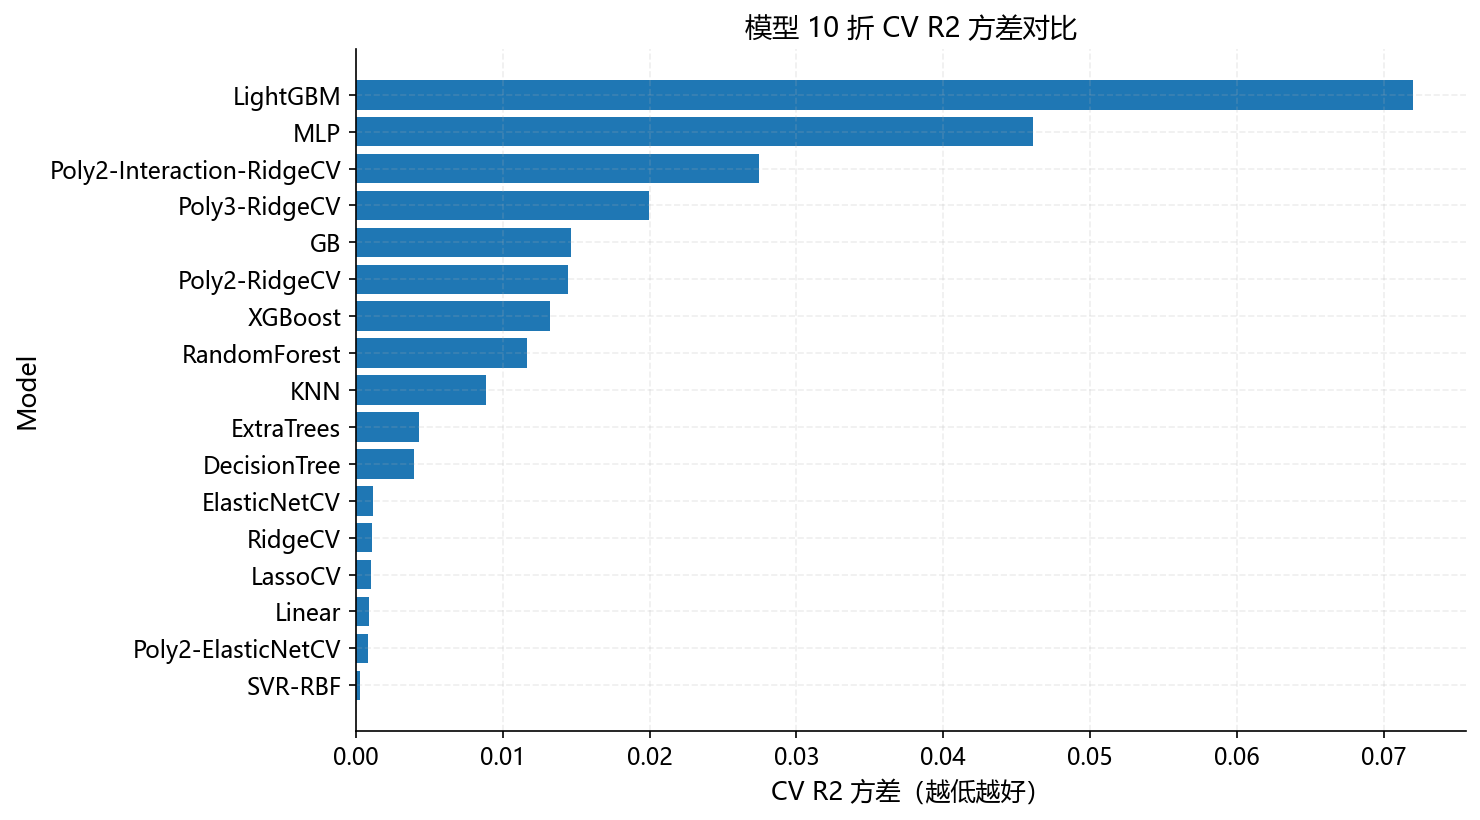

In [10]:
# ---------- 3b) Stability metric visualization: CV R² variance ----------
fig, ax = plt.subplots(figsize=(10, 5.6))
plot_df_sorted = metrics_df.sort_values("cv_r2_variance", ascending=True)
ax.barh(plot_df_sorted["model"], plot_df_sorted["cv_r2_variance"])
ax.set_title("模型 10 折 CV R2 方差对比")
ax.set_xlabel("CV R2 方差（越低越好）")
ax.set_ylabel("Model")
fig.tight_layout()
fig.savefig(FIG_DIR / "model_cv_r2_variance.png", bbox_inches="tight")
plt.show()

<!-- CODEx bilingual cell explanation: start -->
### Cell 11 — 最佳模型保存 / Best-model persistence

**中文说明**：选择测试集表现最好的两个模型，保存 joblib 文件、最佳参数和模型名称，为 Step 4 的 OCEI 模型重建和后续复现提供输入。

**输入与依赖**：依赖上游特征矩阵、目标变量、候选模型或交叉验证设置。

**主要输出**：输出拟合模型、评价指标、交叉验证结果、预测值或模型参数表。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Selects the top two test-set models, saves joblib files, best-parameter records, and model names, providing inputs for Step 4 carbon-intensity modelling and later reproduction.

**Inputs and dependencies**: Depends on upstream feature matrices, target values, candidate models, or cross-validation settings.

**Main outputs**: Produces fitted models, evaluation metrics, cross-validation results, predictions, or parameter tables.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


In [11]:
best2 = metrics_df.head(2)["model"].tolist()
print("Top 2 models:", best2)

final_models = {}
best_params_rows = []

for name in best2:
    model = fitted_models[name]
    final_models[name] = model
    joblib.dump(model, MODEL_DIR / f"{name}_eui_model.joblib")

    row = metrics_df.loc[metrics_df["model"] == name].iloc[0]
    best_params_rows.append({
        "model": name,
        "best_params": row["best_params"]
    })

pd.DataFrame(best_params_rows).to_csv(
    OUT_DIR / "best_model_params.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.Series(best2, name="best2_models").to_csv(
    OUT_DIR / "best2_models.csv",
    index=False,
    encoding="utf-8-sig"
)

Top 2 models: ['Linear', 'RidgeCV']


<!-- CODEx bilingual cell explanation: start -->
### Cell 12 — 泛化间隙图 / Generalization-gap chart

**中文说明**：计算并绘制 train R2 - test R2，识别过拟合风险。该图直接回应高精度结果是否可能由训练集记忆或信息泄漏造成。

**输入与依赖**：读取当前工作流已经生成的数据表或内存对象，并使用统一的绘图样式。

**主要输出**：导出论文或复核用图像文件，并在必要时同步导出支撑图表的数据表。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Computes and plots train R2 minus test R2 to identify overfitting risk. The chart directly addresses whether high predictive performance could result from memorisation or leakage.

**Inputs and dependencies**: Uses data tables or in-memory objects already produced in the workflow with a consistent plotting style.

**Main outputs**: Exports manuscript or audit figures and, when needed, the source tables behind the figure.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


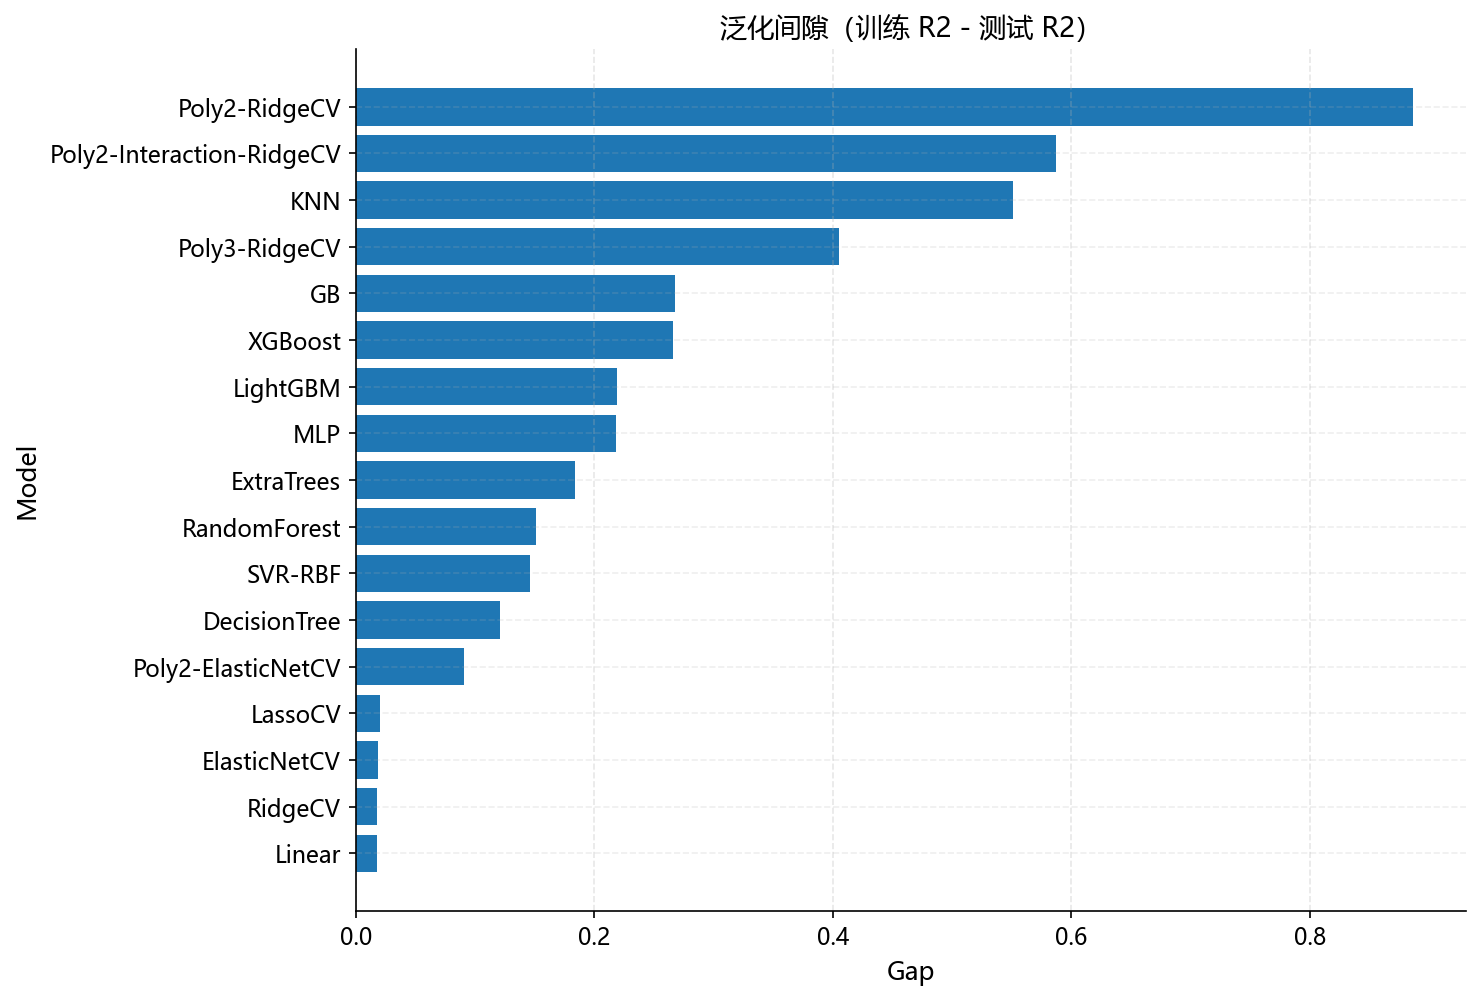

In [12]:
# ----------- 4) Generalization-gap visualization -----------
gap_df = metrics_df.copy()
gap_df["generalization_gap"] = gap_df["train_r2"] - gap_df["test_r2"]

# Sort by the gap in descending order to identify stronger overfitting.
gap_df = gap_df.sort_values("generalization_gap", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6.8))
ax.barh(gap_df["model"], gap_df["generalization_gap"])
ax.set_title("泛化间隙（训练 R2 - 测试 R2）")
ax.set_xlabel("Gap")
ax.set_ylabel("Model")
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Place the largest gap at the top.
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIG_DIR / "generalization_gap.png", bbox_inches="tight", dpi=300)
plt.show()

<!-- CODEx bilingual cell explanation: start -->
### Cell 13 — 预测值与仿真值对比图 / Predicted-versus-simulated plots

**中文说明**：为前两名模型绘制测试集预测 EUI 与 EnergyPlus 仿真 EUI 的散点图，并标注 R2、CV 方差、RMSE 和 MAPE。该图表述为代理模型对仿真标签的保真度，而非真实建筑预测精度。

**输入与依赖**：读取当前工作流已经生成的数据表或内存对象，并使用统一的绘图样式。

**主要输出**：导出论文或复核用图像文件，并在必要时同步导出支撑图表的数据表。

**复现提示**：运行前确认上游输出路径存在；若当前单元生成图件，需同时检查 PNG 预览和 SVG/PDF 矢量文件的文字完整性、标签间距和图例位置。

**English explanation**: Plots predicted EUI against EnergyPlus-simulated EUI for the top two models and annotates R2, CV variance, RMSE, and MAPE. The plot is framed as surrogate fidelity to simulation labels, not real-building prediction accuracy.

**Inputs and dependencies**: Uses data tables or in-memory objects already produced in the workflow with a consistent plotting style.

**Main outputs**: Exports manuscript or audit figures and, when needed, the source tables behind the figure.

**Reproducibility note**: Confirm upstream output paths before running. For figure-producing cells, inspect both PNG previews and SVG/PDF vector exports for complete text, label spacing, and legend placement.
<!-- CODEx bilingual cell explanation: end -->


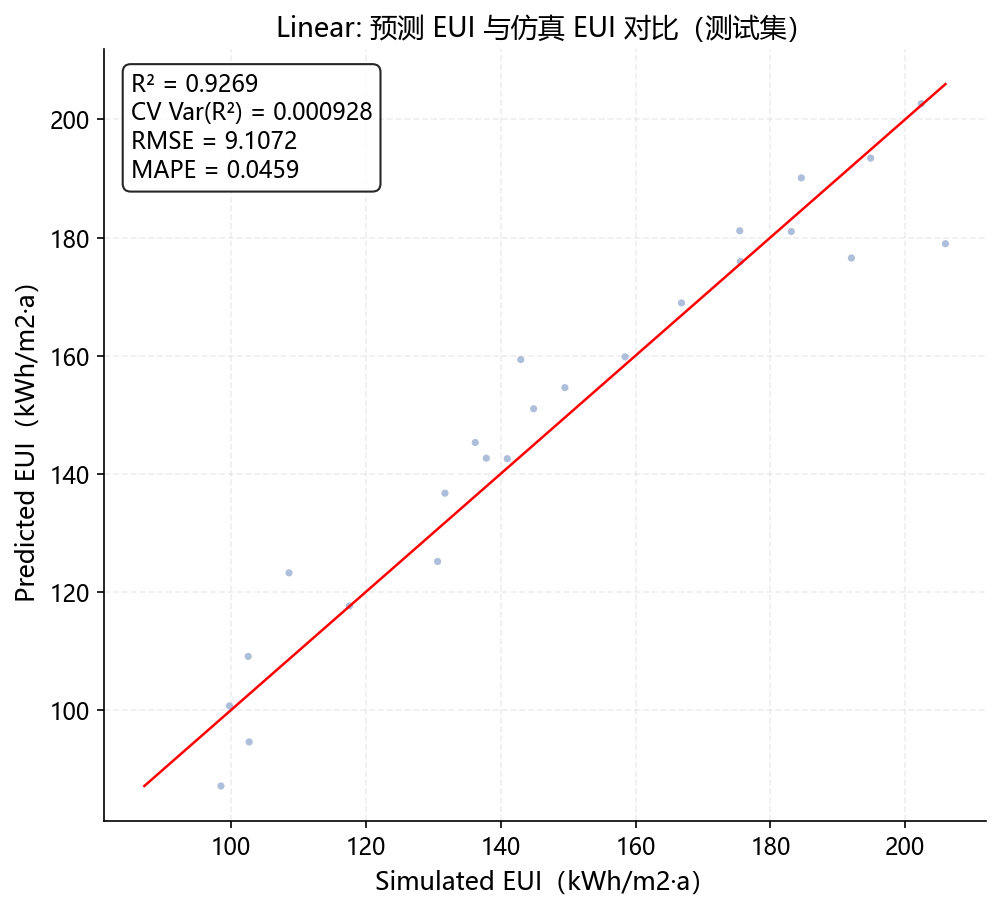

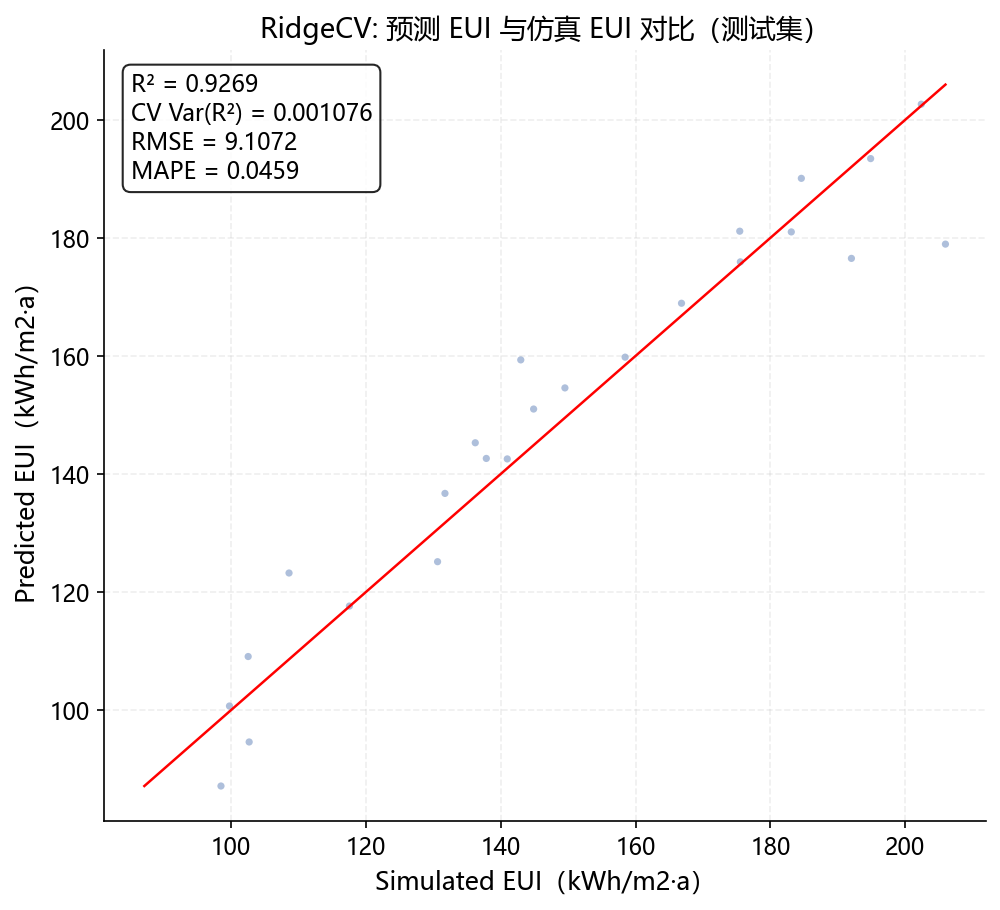

In [13]:
for name in best2:
    model = fitted_models[name]
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred)

    fig, ax = plt.subplots(figsize=(6.8, 6.2))
    ax.scatter(
        y_test, pred,
        s=12,
        alpha=0.45,
        color="#4C72B0",
        edgecolors="none",
        rasterized=True
    )

    lo = min(y_test.min(), np.min(pred))
    hi = max(y_test.max(), np.max(pred))
    ax.plot([lo, hi], [lo, hi], linewidth=1.2, color='red')

    ax.set_title(f"{name}: 预测 EUI 与仿真 EUI 对比（测试集）")
    ax.set_xlabel("Simulated EUI（kWh/m2·a）")
    ax.set_ylabel("Predicted EUI（kWh/m2·a）")

    row = metrics_df.loc[metrics_df["model"] == name].iloc[0]
    
    txt = (
        f"R² = {r2:.4f}\n"
        f"CV Var(R²) = {row['cv_r2_variance']:.6f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"MAPE = {mape:.4f}"
    )
    ax.text(
        0.03, 0.97, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85)
    )

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}_pred_vs_sim_test.png", bbox_inches="tight")
    plt.show()

    pred_df = pd.DataFrame({
        "y_true": y_test.values,
        "y_pred": pred
    })
    pred_df.to_csv(
        OUT_DIR / f"{name}_test_predictions.csv",
        index=False,
        encoding="utf-8-sig"
    )